# Deep Learning Lab EX2
Comparative Study of Activation Functions and Optimization Algorithms
Dataset: Fashion MNIST

## Part A - Activation Function Visualization

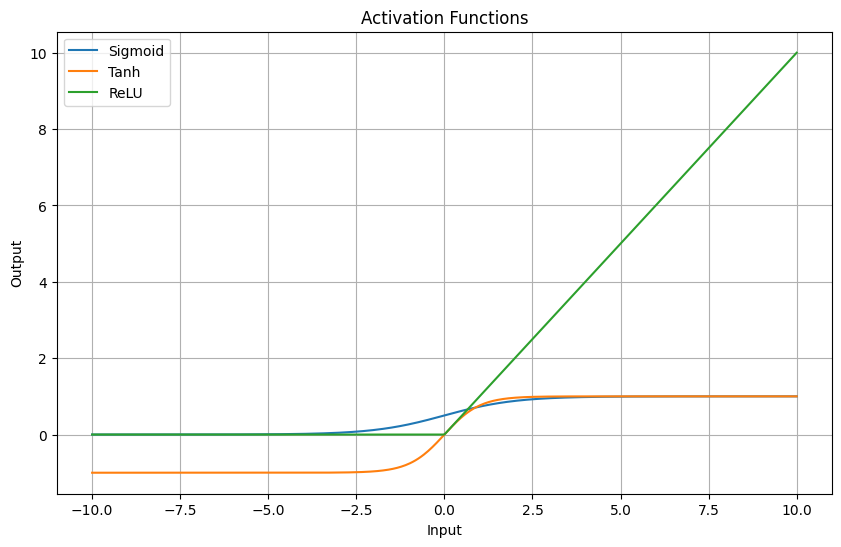

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x=np.linspace(-10,10,500)
sigmoid=1/(1+np.exp(-x))
tanh=np.tanh(x)
relu=np.maximum(0,x)

plt.figure(figsize=(10,6))
plt.plot(x,sigmoid,label='Sigmoid')
plt.plot(x,tanh,label='Tanh')
plt.plot(x,relu,label='ReLU')
plt.title('Activation Functions')
plt.xlabel('Input')
plt.ylabel('Output')
plt.grid(True)
plt.legend()
plt.show()


## Common Imports and Dataset

In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten,Dense
from tensorflow.keras.optimizers import SGD,RMSprop,Adam
import matplotlib.pyplot as plt

(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()
x_train=x_train.astype('float32')/255.0
x_test=x_test.astype('float32')/255.0

print('Training:',x_train.shape)
print('Testing:',x_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training: (60000, 28, 28)
Testing: (10000, 28, 28)


## Part B - Activation Function Comparison

In [3]:
def create_activation_model(act):
    model=Sequential([
        Flatten(input_shape=(28,28)),
        Dense(128,activation=act),
        Dense(64,activation=act),
        Dense(10,activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

histories={}
for act in ['sigmoid','tanh','relu']:
    print(f'\nTraining with {act}')
    m=create_activation_model(act)
    h=m.fit(x_train,y_train,epochs=10,batch_size=32,
            validation_data=(x_test,y_test),verbose=1)
    histories[act]=h

print('\nFinal Results')
for act,h in histories.items():
    print(act,
          h.history['accuracy'][-1],
          h.history['val_accuracy'][-1],
          h.history['loss'][-1],
          h.history['val_loss'][-1])



Training with sigmoid


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7979 - loss: 0.6092 - val_accuracy: 0.8391 - val_loss: 0.4484
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8602 - loss: 0.3873 - val_accuracy: 0.8528 - val_loss: 0.4072
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8739 - loss: 0.3486 - val_accuracy: 0.8607 - val_loss: 0.3785
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8810 - loss: 0.3265 - val_accuracy: 0.8673 - val_loss: 0.3647
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8873 - loss: 0.3076 - val_accuracy: 0.8639 - val_loss: 0.3727
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8917 - loss: 0.2949 - val_accuracy: 0.8767 - val_loss: 0.3408
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8957 - loss: 0.2807 - val_accuracy: 0.8723 - val_loss: 0.3487
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9007 - loss: 0.2705 -

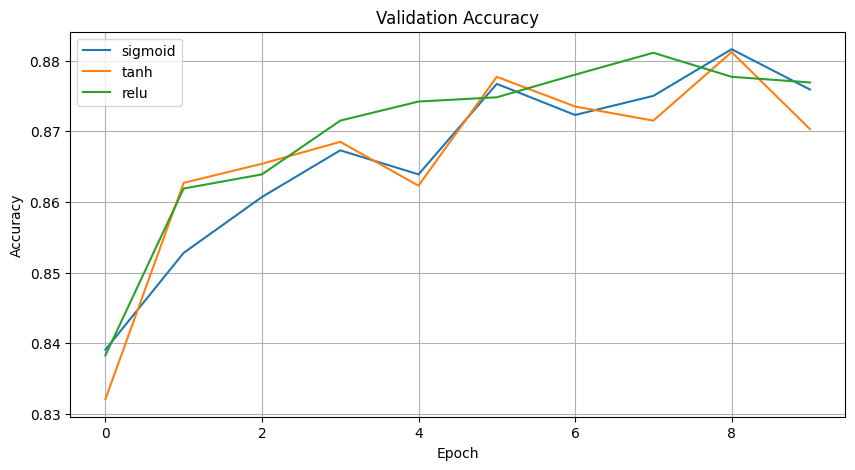

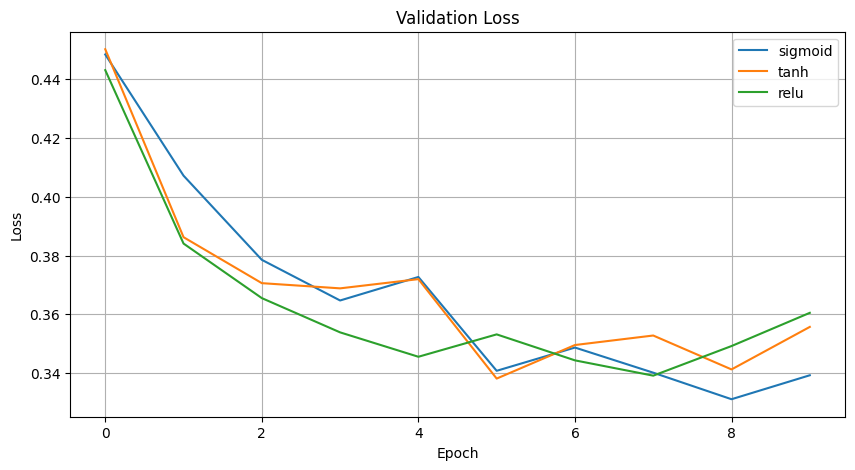

In [5]:
plt.figure(figsize=(10,5))
for k,h in histories.items():
    plt.plot(h.history['val_accuracy'],label=k)
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(); plt.grid(); plt.show()

plt.figure(figsize=(10,5))
for k,h in histories.items():
    plt.plot(h.history['val_loss'],label=k)
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(); plt.grid(); plt.show()

## Part C - Optimizer Comparison

In [6]:
def create_optimizer_model(opt):
    model=Sequential([
        Flatten(input_shape=(28,28)),
        Dense(128,activation='relu'),
        Dense(64,activation='relu'),
        Dense(10,activation='softmax')
    ])
    model.compile(optimizer=opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

opts={
'SGD':SGD(learning_rate=0.01),
'Momentum':SGD(learning_rate=0.01,momentum=0.9),
'RMSprop':RMSprop(),
'Adam':Adam()
}

opt_hist={}
for name,opt in opts.items():
    print(f'\nTraining with {name}')
    m=create_optimizer_model(opt)
    h=m.fit(x_train,y_train,epochs=10,batch_size=32,
            validation_data=(x_test,y_test),verbose=1)
    opt_hist[name]=h

print('\nFinal Results')
for n,h in opt_hist.items():
    print(n,
          h.history['accuracy'][-1],
          h.history['val_accuracy'][-1],
          h.history['loss'][-1],
          h.history['val_loss'][-1])



Training with SGD
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7573 - loss: 0.7336 - val_accuracy: 0.8099 - val_loss: 0.5437
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8277 - loss: 0.4915 - val_accuracy: 0.8322 - val_loss: 0.4833
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8424 - loss: 0.4460 - val_accuracy: 0.8370 - val_loss: 0.4630
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8541 - loss: 0.4165 - val_accuracy: 0.8378 - val_loss: 0.4632
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8587 - loss: 0.3979 - val_accuracy: 0.8521 - val_loss: 0.4208
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8649 - loss: 0.3822 - val_accuracy: 0.8524 - val_loss: 0.4213
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8675 - loss: 0.3706 - val_accuracy: 0.8588 - val_loss: 0.3994
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.872

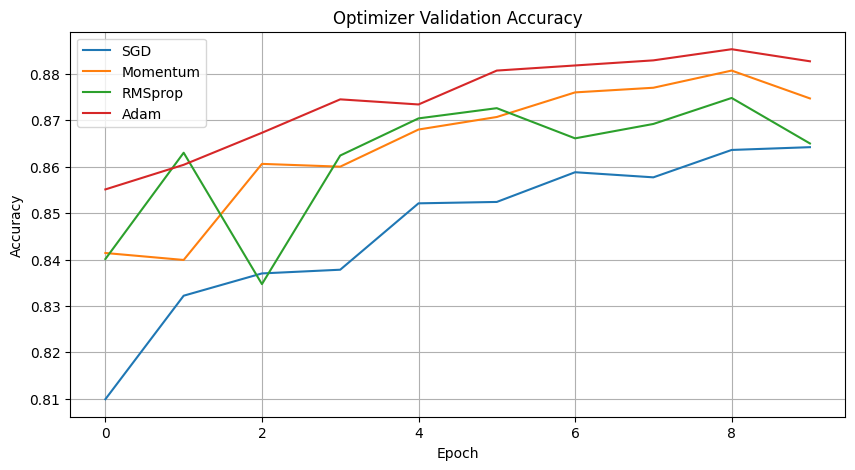

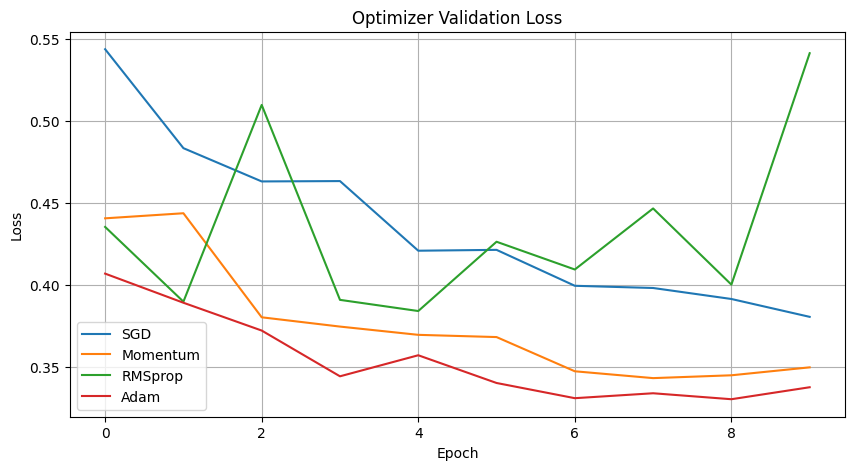

In [7]:
plt.figure(figsize=(10,5))
for k,h in opt_hist.items():
    plt.plot(h.history['val_accuracy'],label=k)
plt.title('Optimizer Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(); plt.show()

plt.figure(figsize=(10,5))
for k,h in opt_hist.items():
    plt.plot(h.history['val_loss'],label=k)
plt.title('Optimizer Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(); plt.show()


## Part D - Experiment Management

In [9]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [10]:
# Save final model (using Adam model from Part C)
final_model=m
final_model.save('/content/drive/MyDrive/fashion_mnist_model.keras')
print('Model saved.')


Model saved.
